<img align="right" style="padding-left:50px;" src="figures_wk1/answering_questions.png" width=350><br>
# Week 1 Lab: Defining and Investigating Analytical Questions

As noted in our lecture notebook this week, the main purpose of data analytics is to answer questions about a dataset. This week you will practice developing questions about a dataset and then answer those questions using python's Pandas library.

##  Our Dataset
**Dataset Name::** Movie Lens dataset
GroupLens Research has collected and made available rating data sets from the MovieLens web site (https://movielens.org).
The dataset is comprised of 3 seperate files: movies.dat, ratings.dat, users.dat.


**Reminder:** The first step in any type of data analysis is to <u>look</u> at your data.

In [ ]:
!head assign_wk1/movies.dat

1;Toy Story (1995);Animation|Children's|Comedy
2;Jumanji (1995);Adventure|Children's|Fantasy
3;Grumpier Old Men (1995);Comedy|Romance
4;Waiting to Exhale (1995);Comedy|Drama
5;Father of the Bride Part II (1995);Comedy
6;Heat (1995);Action|Crime|Thriller
7;Sabrina (1995);Comedy|Romance
8;Tom and Huck (1995);Adventure|Children's
9;Sudden Death (1995);Action
10;GoldenEye (1995);Action|Adventure|Thriller


In [ ]:
!pwd

/Users/christypearson/Documents/Regis/Faculty/MSDS/MSDS650/CourseMaterial/Week_1


In [ ]:
!head assign_wk1/ratings.dat

1;1193;5;978300760
1;661;3;978302109
1;914;3;978301968
1;3408;4;978300275
1;2355;5;978824291
1;1197;3;978302268
1;1287;5;978302039
1;2804;5;978300719
1;594;4;978302268
1;919;4;978301368


In [ ]:
!head assign_wk1/users.dat

1;F;1;10;48067
2;M;56;16;70072
3;M;25;15;55117
4;M;45;7;02460
5;M;25;20;55455
6;F;50;9;55117
7;M;35;1;06810
8;M;25;12;11413
9;M;25;17;61614
10;F;35;1;95370


Hmmm.... Well it appears that all 3 of our data files do not include a header row.  So we are going to need to define a header row for each of the 3 files. The accompanying README file denotes the fileds for each of these files.

<div class="alert alert-block alert-info">
    <b>File Separator::</b> Did you notice that seperator in the file is not a comma?  We will need to account for that when we load each file into a Pandas dataframe. <br> <br>
The README file has additional useful information that you might want to refer while working on this assignment.
</div>

In [ ]:
import pandas as pd

In [ ]:
# movie.dat fields --> MovieID::Title::Genres

m_cols = ['movie_id', 'title', 'genres']
movies_df = pd.read_csv('/content/movies.dat', sep=';', names=m_cols, encoding='latin1')
movies_df.head(10)

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children's
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [ ]:
# ratings.dat fields --> UserID::MovieID::Rating::Timestamp
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings_df = pd.read_csv('/content/ratings.dat', sep=';', names=r_cols)
ratings_df.head(10)

,user_id,movie_id,rating,unix_timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


In [ ]:
# users.dat fields --> UserID::Gender::Age::Occupation::Zip-code
u_cols = ['user_id','sex', 'age', 'occupation', 'zip_code']
users_df = pd.read_csv('/content/users.dat', sep=';', names=u_cols)
users_df.head(10)

,user_id,sex,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
5,6,F,50,9,55117
6,7,M,35,1,06810
7,8,M,25,12,11413
8,9,M,25,17,61614
9,10,F,35,1,95370


Now we can merge the individal dataframes into a single dataframe.

In [ ]:
# merge movies_df with ratings_df
movie_ratings_df = pd.merge(movies_df, ratings_df)

# now movies_ratings_df with users_df
lens_df = pd.merge(movie_ratings_df, users_df)
lens_df.head(20)

,movie_id,title,genres,user_id,rating,unix_timestamp,sex,age,occupation,zip_code
0,1,Toy Story (1995),Animation|Children's|Comedy,1,5,978824268,F,1,10,48067
1,48,Pocahontas (1995),Animation|Children's|Musical|Romance,1,5,978824351,F,1,10,48067
2,150,Apollo 13 (1995),Drama,1,5,978301777,F,1,10,48067
3,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,1,4,978300760,F,1,10,48067
4,527,Schindler's List (1993),Drama|War,1,5,978824195,F,1,10,48067
5,531,"Secret Garden, The (1993)",Children's|Drama,1,4,978302149,F,1,10,48067
6,588,Aladdin (1992),Animation|Children's|Comedy|Musical,1,4,978824268,F,1,10,48067
7,594,Snow White and the Seven Dwarfs (1937),Animation|Children's|Musical,1,4,978302268,F,1,10,48067
8,595,Beauty and the Beast (1991),Animation|Children's|Musical,1,5,978824268,F,1,10,48067
9,608,Fargo (1996),Crime|Drama|Thriller,1,4,978301398,F,1,10,48067


In [ ]:
lens_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   movie_id        1000209 non-null  int64 
 1   title           1000209 non-null  object
 2   genres          1000209 non-null  object
 3   user_id         1000209 non-null  int64 
 4   rating          1000209 non-null  int64 
 5   unix_timestamp  1000209 non-null  int64 
 6   sex             1000209 non-null  object
 7   age             1000209 non-null  int64 
 8   occupation      1000209 non-null  int64 
 9   zip_code        1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 83.9+ MB


In [ ]:
lens_df.shape

(1000209, 10)

In [ ]:
lens_df.to_csv('movie_lens_merged.csv',index=False)

# Assignment Requirements
Here are the requirements for this week's assignment. Make sure you address all of the assignment steps in your submission.
1) Above, I demostrated using a `info()` and `shape` functions with our lens_df data structure.
    * Describe what both of these functions are used for?
    * What information is returned from these functions?
    * Why is this information helpful?
2) Using the functions demonstrated in `1_Defining_Analytical_Questions.ipynb` answer the following questions:
    * Which movie(s) has the highest average rating?
        * What about the movie(s) with the lowest rating?
    * Which movie(s) has the most ratings in our dataset?
    * List the 10 users who have rated the most movies?
3) Define at least 5 analytical questions you would like to investigate for this dataset. As demonstrated in the lecture materials, you can define the scope of your analysis for each of your questions. However, throughout the investigation of questions, make sure you demonstrate each of the following functions at least once:
    * Data Visualization: histrgrams, boxplots
    * Descriptive functions: info(), describe(), shape
    * Dataframe reshaping: removal of rows or columns
    * Functions:
         * apply()
         * lambda()
         * aggregration (.agg)
         * groupby()
    * Conditional formatting in a dataframe

# Deliverables
Upload your Jupyter Notebook to the corresponding location in WorldClass.

**Note::** Make sure you have clearly indicated each assignment requirement within your notebook. Also, I <u><i><b>highly encourage</b></i></u> you to use markdown text to create a notebook that integrates your analysis within your code. Refer to the GettingStarted notebook to understand the difference between markdown text and comments.

# Additional functionality that might be useful

The function unstack() and reset_index() might be helpful for your investigation. You can read more about these two functions on the Pandas doc pages.
* unstack(): https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html#
* reset_index(): https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html

In the code below, notice how unstack() and reset_index() reshape the output of the groupby() function.

In [ ]:
lens_df.groupby(['title']).agg({'rating':['count']})

,rating
,count
title,
"$1,000,000 Duck (1971)",37
'Night Mother (1986),70
'Til There Was You (1997),52
"'burbs, The (1989)",303
...And Justice for All (1979),199
...,...
"Zed & Two Noughts, A (1985)",29
Zero Effect (1998),301


In [ ]:
sum_df = lens_df.groupby('title').agg({'rating':'count'}).unstack()
sum_df

        title                                     
rating  $1,000,000 Duck (1971)                         37
        'Night Mother (1986)                           70
        'Til There Was You (1997)                      52
        'burbs, The (1989)                            303
        ...And Justice for All (1979)                 199
                                                     ... 
        Zed & Two Noughts, A (1985)                    29
        Zero Effect (1998)                            301
        Zero Kelvin (Kjærlighetens kjøtere) (1995)      2
        Zeus and Roxanne (1997)                        23
        eXistenZ (1999)                               410
Length: 3706, dtype: int64

In [ ]:
sum_df = lens_df.groupby(['title']).agg({'rating':['count']}).unstack()
sum_df

               title                                     
rating  count  $1,000,000 Duck (1971)                         37
               'Night Mother (1986)                           70
               'Til There Was You (1997)                      52
               'burbs, The (1989)                            303
               ...And Justice for All (1979)                 199
                                                            ... 
               Zed & Two Noughts, A (1985)                    29
               Zero Effect (1998)                            301
               Zero Kelvin (Kjærlighetens kjøtere) (1995)      2
               Zeus and Roxanne (1997)                        23
               eXistenZ (1999)                               410
Length: 3706, dtype: int64

In [ ]:
sum_df = lens_df.groupby(['title']).agg({'rating':['count']}).unstack().reset_index()
sum_df

,level_0,level_1,title,0
0,rating,count,"$1,000,000 Duck (1971)",37
1,rating,count,'Night Mother (1986),70
2,rating,count,'Til There Was You (1997),52
3,rating,count,"'burbs, The (1989)",303
4,rating,count,...And Justice for All (1979),199
...,...,...,...,...
3701,rating,count,"Zed & Two Noughts, A (1985)",29
3702,rating,count,Zero Effect (1998),301
3703,rating,count,Zero Kelvin (Kjærlighetens kjøtere) (1995),2
3704,rating,count,Zeus and Roxanne (1997),23


In [ ]:
avg = new_df.groupby(['title']).agg ( {'rating' : 'mean'} ).round(2).sort_values(by=['rating'], ascending=False)
avg

NameError: name 'new_df' is not defined

In [1]:
import pandas as pd

In [3]:
lens_df=pd.read_csv('/content/movie_lens_merged.csv')

In [ ]:
lens_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508318 entries, 0 to 508317
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   movie_id        508318 non-null  int64  
 1   title           508318 non-null  object 
 2   genres          508318 non-null  object 
 3   user_id         508317 non-null  float64
 4   rating          508317 non-null  float64
 5   unix_timestamp  508317 non-null  float64
 6   sex             508317 non-null  object 
 7   age             508317 non-null  float64
 8   occupation      508317 non-null  float64
 9   zip_code        508317 non-null  object 
dtypes: float64(5), int64(1), object(4)
memory usage: 38.8+ MB


In [ ]:
lens_df=pd.read_csv('/content/movie_lens_merged.csv')

# info and shape function description

In [ ]:
lens_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   movie_id        1000209 non-null  int64 
 1   title           1000209 non-null  object
 2   genres          1000209 non-null  object
 3   user_id         1000209 non-null  int64 
 4   rating          1000209 non-null  int64 
 5   unix_timestamp  1000209 non-null  int64 
 6   sex             1000209 non-null  object
 7   age             1000209 non-null  int64 
 8   occupation      1000209 non-null  int64 
 9   zip_code        1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


info function gives information about the column names and datatypes of the columns and number of non null values count and memory usage.This can be helpful in preprocessing like understanding the numerical columns

In [ ]:
lens_df.shape

(1000209, 10)

Shape function gives the number of rows and columns of dataframe.This is used in finding dimension of the dataframe

# Analytical Questions

In [ ]:
avg_ratings = lens_df.groupby('title')['rating'].mean()


In [ ]:
avg_ratings.head()

,rating
title,
"$1,000,000 Duck (1971)",3.027027
'Night Mother (1986),3.371429
'Til There Was You (1997),2.692308
"'burbs, The (1989)",2.910891
...And Justice for All (1979),3.713568


# Which movie(s) has the highest average rating?

In [ ]:
highest_avg_rating = avg_ratings[avg_ratings == avg_ratings.max()]


In [ ]:
highest_avg_rating

,rating
title,
"Baby, The (1973)",5.0
Bittersweet Motel (2000),5.0
Follow the Bitch (1998),5.0
"Gate of Heavenly Peace, The (1995)",5.0
Lured (1947),5.0
One Little Indian (1973),5.0
Schlafes Bruder (Brother of Sleep) (1995),5.0
Smashing Time (1967),5.0
Song of Freedom (1936),5.0


The movies like Baby, The (1973),Bittersweet Motel (2000) has the highest 5 average rating

# What about the movie(s) with the lowest rating?

In [ ]:
lowest_avg_rating = avg_ratings[avg_ratings == avg_ratings.min()]

In [ ]:
lowest_avg_rating

,rating
title,
"Blood Spattered Bride, The (La Novia Ensangrentada) (1972)",1.0
"Bloody Child, The (1996)",1.0
Cheetah (1989),1.0
Diebinnen (1995),1.0
Elstree Calling (1930),1.0
Even Dwarfs Started Small (Auch Zwerge haben klein angefangen) (1971),1.0
"Fantastic Night, The (La Nuit Fantastique) (1949)",1.0
Get Over It (1996),1.0
Hillbillys in a Haunted House (1967),1.0


The movies like Bloody Child, The (1996),Cheetah (1989) have the lowest average rating and it is one

# Which movie(s) has the most ratings in our dataset?

In [ ]:
most_rated_movies = lens_df['title'].value_counts().head(10)

In [ ]:
most_rated_movies

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
Saving Private Ryan (1998),2653
Terminator 2: Judgment Day (1991),2649
"Matrix, The (1999)",2590
Back to the Future (1985),2583


Most rated movie is american beauty with 3428 ratings

# List the 10 users who have rated the most movies?

In [ ]:
most_rated_user = lens_df['user_id'].value_counts().head(10)

In [ ]:
most_rated_user

,count
user_id,
4169,2314
1680,1850
4277,1743
1941,1595
1181,1521
889,1518
3618,1344
2063,1323
1150,1302


Most rated user is with user id 4169 with 2314 ratings followed by 1680 user with 1850 ratings

#  Define at least 5 analytical questions you would like to investigate for this dataset.

# What is the average rating for each genre?

In [8]:
genre_avg_rating = lens_df.groupby('genres')['rating'].mean()

In [9]:
top_genere_avg_rating=genre_avg_rating.sort_values(ascending=False).head(10)

In [12]:
top_genere_avg_rating

,rating
genres,
Animation|Comedy|Thriller,4.473837
Sci-Fi|War,4.449890
Animation,4.394336
Film-Noir|Mystery,4.367424
Adventure|War,4.346107
Film-Noir|Romance|Thriller,4.294382
Action|Adventure|Drama|Sci-Fi|War,4.292977
Film-Noir|Sci-Fi,4.273333
Crime|Film-Noir,4.264129


Here average rating is founf for genres and there are total 301 generes with
 Animation|Comedy|Thriller genre having 4.473837 rating

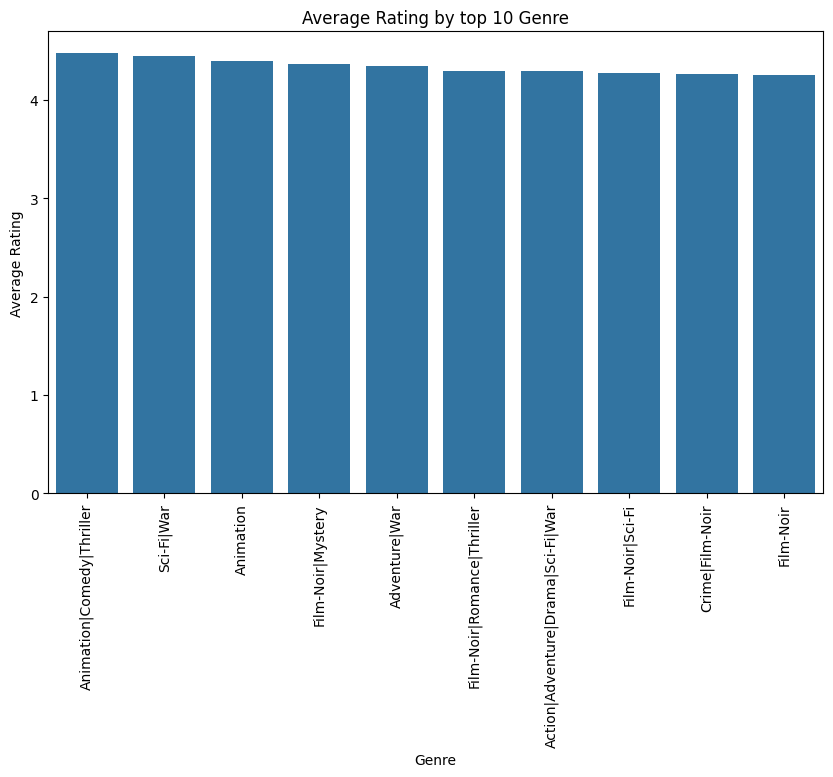

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genere_avg_rating.index, y=top_genere_avg_rating.values)
plt.title('Average Rating by top 10 Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)
plt.show()

# Correlation between User Age and Average Rating

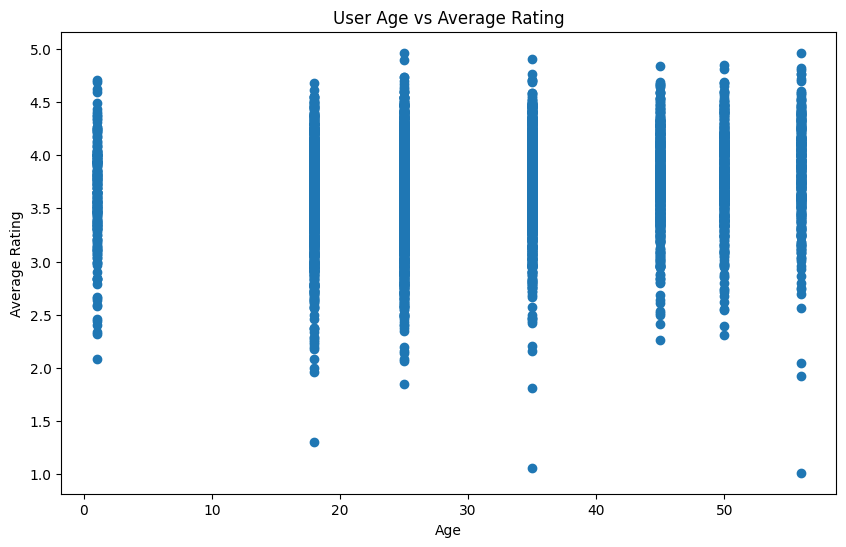

Correlation between age and average rating: 0.15


In [ ]:
user_avg_ratings = lens_df.groupby('user_id').agg({'rating': 'mean', 'age': 'first'})

plt.figure(figsize=(10, 6))
plt.scatter(user_avg_ratings['age'], user_avg_ratings['rating'])
plt.title('User Age vs Average Rating')
plt.xlabel('Age')
plt.ylabel('Average Rating')
plt.show()

correlation = user_avg_ratings['age'].corr(user_avg_ratings['rating'])
print(f"Correlation between age and average rating: {correlation:.2f}")

The correlation between age and average rating is very less and it is .15.THis indicates that correlation is not statistically significant and this finding suggests that age is not a strong predictor of average rating.

# differences in average ratings across geographic regions

In [ ]:
zip_code_ratings = lens_df.groupby('zip_code').agg(rating_count=('rating', 'count'), avg_rating=('rating', 'mean'))

In [ ]:
zip_code_ratings.sort_values(by='avg_rating',ascending=False)

,rating_count,avg_rating
zip_code,,
46239,165,4.890909
12570,103,4.796117
93060,25,4.760000
95062,25,4.760000
30349,196,4.734694
...,...,...
85054,170,2.088235
21555,230,2.060870
46140,55,1.927273


The users in 46239 pincode gave higest average rating which is 4.89

In [ ]:
zip_code_ratings.sort_values(by='rating_count',ascending=False)

,rating_count,avg_rating
zip_code,,
94110,3802,3.615203
60640,3430,3.423615
98103,3204,3.652310
95616,3079,3.869438
02138,3019,3.472011
...,...,...
48146,20,3.550000
81291,20,3.300000
53222,20,4.200000


Users from 94110 pincode gave more ratings that is 3802 ratings

# How do rating patterns change over time

In [ ]:
lens_df['year'] = pd.to_datetime(lens_df['unix_timestamp'], unit='s').dt.year
rating_trends_over_time = lens_df.groupby('year')['rating'].mean()

In [ ]:
rating_trends_over_time

,rating
year,
2000,3.590392
2001,3.512254
2002,3.458829
2003,3.486559


We can see that rating patterns are decresing till 2002 whereas in 2003 there was slight increase with the highest rating in 2000 is of 3.59

In [ ]:
lens_df['month'] = pd.to_datetime(lens_df['unix_timestamp'], unit='s').dt.month
seasonal_trends = lens_df.groupby('month')['rating'].mean()

# seasonal trends in ratings

In [ ]:
seasonal_trends

,rating
month,
1,3.542996
2,3.523664
3,3.456952
4,3.522028
5,3.601847
6,3.616528
7,3.617985
8,3.566315
9,3.602279


There is no much difference in ratings in months and it varies in the range of 3.45 to 3.62 with the lowest in march and highest in july

# Average rating of movies with atleast 100 ratings

In [ ]:
movie_counts = lens_df['title'].value_counts()
popular_movies = movie_counts.index[movie_counts >= 100]

filtered_lens = lens_df[lens_df['title'].isin(popular_movies)]
average_ratings = filtered_lens.groupby('title')['rating'].mean()

print(average_ratings.sort_values(ascending=False).head(10))

title
Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)    4.560510
Shawshank Redemption, The (1994)                                       4.554558
Godfather, The (1972)                                                  4.524966
Close Shave, A (1995)                                                  4.520548
Usual Suspects, The (1995)                                             4.517106
Schindler's List (1993)                                                4.510417
Wrong Trousers, The (1993)                                             4.507937
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)                          4.491489
Raiders of the Lost Ark (1981)                                         4.477725
Rear Window (1954)                                                     4.476190
Name: rating, dtype: float64


There are total 2019 movies which are rated more than 100 times and Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)  got the highest rating of 4.56

# most popular generes based on zipcode

In [14]:
genre_popularity = lens_df.groupby(['zip_code', 'genres']).size().reset_index(name='num_ratings')



In [15]:
genre_popularity

,zip_code,genres,num_ratings
0,00231,Action|Adventure|Comedy|Romance,3
1,00231,Action|Adventure|Drama|Romance,1
2,00231,Action|Adventure|Romance,1
3,00231,Action|Adventure|Sci-Fi,1
4,00231,Action|Drama,1
...,...,...,...
269186,99945,Adventure|Animation|Sci-Fi,1
269187,99945,Animation|Children's|Comedy,2
269188,99945,Comedy,3
269189,99945,Drama|Mystery|Sci-Fi|Thriller,1


In [16]:
most_popular_genres = genre_popularity.loc[genre_popularity.groupby('zip_code')['num_ratings'].idxmax()]

In [21]:
most_popular_genres

,zip_code,genres,num_ratings
23,00231,Drama|Romance,22
73,00606,Comedy,39
110,00681,Action|Adventure|Sci-Fi,7
184,00693,Comedy,16
233,00918,Drama,50
...,...,...,...
269087,99703,Comedy,12
269121,99709,Comedy,36
269147,99801,Drama,12
269167,99826,Drama,5


In [30]:
most_popular_genres['zip_code'] [2538:2548]

,zip_code
192363,80207
192437,80209
192534,80210
192609,80218
192692,80220
192728,80221
192846,80222
192981,80227
193118,80228
193185,80230


In [32]:
most_popular_genres[most_popular_genres['zip_code']=='80221']

,zip_code,genres,num_ratings
192728,80221,Drama,5


Most poular genere based on regis university zip code is drama and number of ratings is five.

# summary

**info function :**  info function gives information about the column names and datatypes of the columns and number of non null values count and memory usage.This can be helpful in preprocessing like understanding the numerical columns


**shape function:** Shape function gives the number of rows and columns of dataframe.This is used in finding dimension of the dataframe

**Which movie(s) has the highest average rating?**

The movies like Baby, The (1973),Bittersweet Motel (2000),Follow the Bitch (1998),Gate of Heavenly Peace, The (1995) has the highest 5 average rating


**What about the movie(s) with the lowest rating?**

The movies like Bloody Child, The (1996),Cheetah (1989),Diebinnen (1995),Elstree Calling (1930),Even Dwarfs Started Small (Auch Zwerge haben klein angefangen) (1971) have the lowest average rating and it is one


**Which movie(s) has the most ratings in our dataset?**

Most rated movie is american beauty with 3428 ratings


**List the 10 users who have rated the most movies?**

The least ratings given by 10th user is 1286 .Most rated user is with user id 4169 with 2314 ratings followed by 1680 user with 1850 ratings



**Define at least 5 analytical questions you would like to investigate for this dataset.**


**What is the average rating for each genre?**


Here average rating is found for genres and there are total 301 generes with Animation|Comedy|Thriller genre having 4.473837 rating and Sci-Fi|War having	4.449890 rating  and Animation having	4.394336 and people really seems intrested in animation


**Correlation between User Age and Average Rating**

The correlation between age and average rating is very less and it is .15.THis indicates that correlation is not statistically significant and this finding suggests that age is not a strong predictor of average rating.


**differences in average ratings across geographic regions**

The users in 46239 pincode gave higest average rating which is 4.89 and Users from 94110 pincode gave more ratings that is 3802 ratings




We can see that rating patterns are decresing till 2002 whereas in 2003 there was slight increase with the highest rating in 2000 is of 3.59



**seasonal trends in ratings**


There is no much difference in ratings in months and it varies in the range of 3.45 to 3.62 with the lowest in march and highest in july

**Average rating of movies with atleast 100 ratings**

There are total 2019 movies which are rated more than 100 times and Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954) got the highest rating of 4.56


**most popular generes based on zipcode**

Most poular genere based on regis university zip code is drama and number of ratings given is five.